In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv("../data/processed/train.csv")
valid_df = pd.read_csv("../data/processed/valid.csv")
test_df = pd.read_csv("../data/processed/test.csv")

splits = {
    "train": train_df,
    "valid": valid_df,
    "test": test_df,
}

In [3]:
train_df.head()

,text,label
0,I was seriously looking forward to seeing this...,0
1,"`Mad Dog' Earle is back, along with his sad-sa...",1
2,"* Firstly, although many say it is the worst o...",1
3,"I love science fiction, I am fascinated by Egy...",0
4,One measurement for the greatness of a movie i...,1


In [4]:
for split_name, df in splits.items():
    print(split_name, df.shape)

train (8000, 2)
valid (2000, 2)
test (2000, 2)


In [5]:
for split_name, df in splits.items():
    print(f"\n{split_name}")
    print(df["label"].value_counts().sort_index())


train
label
0    4000
1    4000
Name: count, dtype: int64

valid
label
0    1000
1    1000
Name: count, dtype: int64

test
label
0    1000
1    1000
Name: count, dtype: int64


## Analysis of review length statistics

In [6]:
for df in splits.values():
    df["length"] = df["text"].str.split().apply(len)

In [7]:
for split_name, df in splits.items():
    print(f"\n{split_name}")
    print(df.groupby("label")["length"].describe().round(2))


train
        count    mean     std   min    25%    50%     75%     max
label                                                            
0      4000.0  227.00  164.43  10.0  127.0  170.0  274.25  1368.0
1      4000.0  234.08  177.36  12.0  125.0  173.0  290.00  2459.0

valid
        count    mean     std   min    25%    50%     75%     max
label                                                            
0      1000.0  223.36  156.79  30.0  127.0  174.0  272.00   995.0
1      1000.0  237.82  181.97  27.0  127.0  173.0  293.25  1501.0

test
        count    mean     std   min    25%    50%     75%     max
label                                                            
0      1000.0  233.77  167.21  17.0  129.0  175.0  290.25   993.0
1      1000.0  234.10  179.88  27.0  124.0  170.0  281.25  1138.0


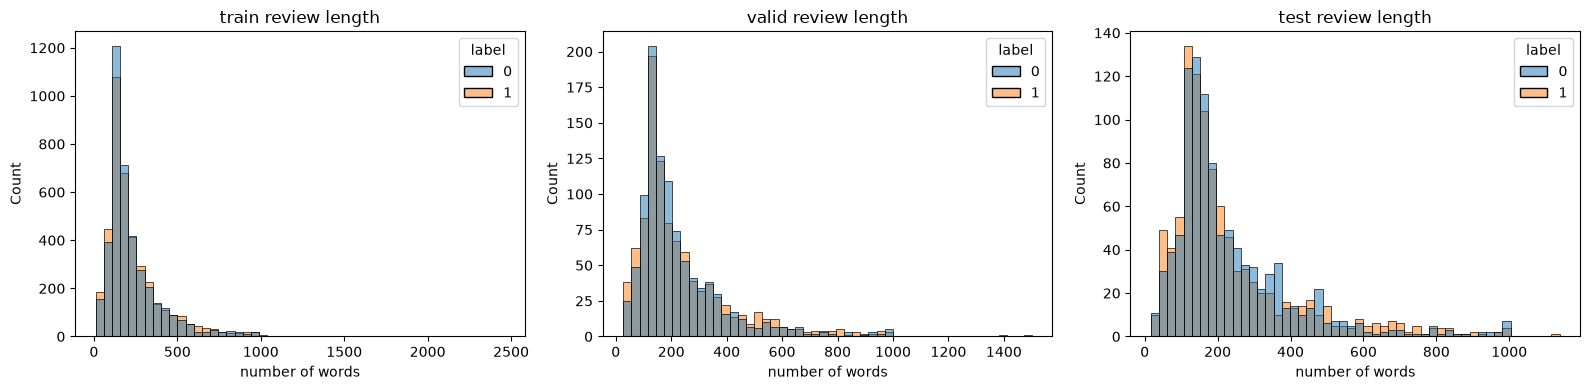

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (split_name, df) in zip(axes, splits.items()):
    sns.histplot(data=df, x="length", hue="label", bins=50, ax=ax)
    ax.set_title(f"{split_name} review length")
    ax.set_xlabel("number of words")

plt.tight_layout()
plt.show()

The review length distributions are similar across sentiment classes and dataset splits. A small number of very long reviews are present, which will require truncation when training transformer-based models.

## Checking for missing values

In [9]:
for split_name, df in splits.items():
    print(f"\n{split_name}")
    print(df.isna().sum())


train
text      0
label     0
length    0
dtype: int64

valid
text      0
label     0
length    0
dtype: int64

test
text      0
label     0
length    0
dtype: int64


## Checking for duplicates

In [10]:
for split_name, df in splits.items():
    duplicates = df["text"].duplicated().sum()
    print(f"{split_name}: {duplicates} duplicate reviews")

train: 0 duplicate reviews
valid: 0 duplicate reviews
test: 0 duplicate reviews


## Check if overlap across splits exists

In [11]:
train_texts = set(train_df["text"])
valid_texts = set(valid_df["text"])
test_texts = set(test_df["text"])

print("train-valid overlap:", len(train_texts & valid_texts))
print("train-test overlap:", len(train_texts & test_texts))
print("valid-test overlap:", len(valid_texts & test_texts))

train-valid overlap: 0
train-test overlap: 0
valid-test overlap: 0


## Sample negative and positive reviews

In [12]:
train_df[train_df["label"] == 0]["text"].sample(3, random_state=42).tolist()

["Most of the episodes on Season 1 are awful..There is no comparison to Twilight Zone or Outer Limits, as they programs actually had decent story lines. Most of Amazing Stories are well dull..not amazing in the least..go rent or buy the Twilight Zone series...I have heard Season 2 of this series is much better..also for some reason on the DVD's they cut out the Ray Walston parts which further diminishes this compilation. The one cool thing is to see actors and actresses when they were younger in 1985...Most of the story lines are very predictable though and the series could of been better with twists and turns that left you wondering...",
 'When I was in school I made a film about a couple roaming around in the trees and talking, and I realized halfway through editing that this was not just a failing aesthetic strategy but a cliché of Canadian cinema: sodden lyricism married to vacant, metaphor-burdened stabs at social commentary. But whatever my own film\'s failings I feel much better

In [13]:
train_df[train_df["label"] == 1]["text"].sample(3, random_state=42).tolist()

['If you have not heard of this film from Walt Disney Pictures, do not worry about it. It would be classed along the other films by Disney that are meant for educational purposes like "Family Planning".  It was co-produced with Kotex to teach pre-teen girls about Menstruation, supposably. It only educates at a superficial level, so it does not go into heavy detail for the animated "Ram\'s Head"/ Reproductive System sequence.  The film does show "The Wonderful World of Disney" elements like the turning of the page and the use of animation to tell the story.  This film is impossible to find, so if you can find the film, best luck to you and enjoy.',
 "Lily Mars, a smalltown girl living in Indiana, dreams of making it big on Broadway and her aspirations are given a lift when successful Broadway producer John Thornway returns to his hometown for a visit. Lily tries everything she can to get Thornway to notice her, but he just gets annoyed with her antics. When Thornway goes back to New Yor